## 05. 콘텐츠 기반 필터링 실습 - TMDB 5000 영화 데이터 세트

TMDB 5000 영화 데이터 세트는 유명한 영화 데이터 정보 사이트인 IMDB의 많은 영화 중 주요 5000개 영화에 대한 메타 정보를 새롭게 가공해 캐글에서 제공하는 데이터 세트이다. 이 TMDB 5000 데이터 세트에 기반해 콘텐츠 기반 필터링을 수행해 보겠다.

## 장르 속성을 이용한 영화 콘텐츠 기반 필터링

콘텐츠 기반 필터링은 사용자가 특정 영화를 감상하고 그 영화를 좋아했다면 그 영화와 비슷한 특성/속성, 구성 요소 등을 가진 다른 영화를 추천하는 것임.

콘텐츠 기반 필터링 추천 시스템을 영화를 선택하는 데 중요한 요소인 영화 장르 속성을 기반으로 만들어 보자. 장르 칼럼 값의 유사도를 비교한 뒤 그중 높은 평점을 가지는 영화를 추천하는 방식이다.

## 데이터 로딩 및 가공


In [4]:
import pandas as pd
import numpy as np
import warnings; warnings.filterwarnings('ignore')

movies = pd.read_csv('/content/tmdb_5000_movies.csv')
print(movies.shape)
movies.head(1)

(4803, 20)


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800


tmdb_5000_movies.csv는 4803개의 레코드와 20개의 피처로 구성돼 있다. 영화 제목, 개요, 인기도, 평점, 투표수, 예산, 키워드 등 영화에 대한 다양한 메타 정보를 가지고 있다. 이 중 콘텐츠 기반 필터링 추천 분석에 사용할 주요 칼럼만 추출해 새롭게 DataFrame으로 만들겠다. 추출할 주요 칼럼은 id, 영화제목 title, 영화가 속한 여러 가지 장르인 genres, 평균 평점인 vote_average, 평점 투표수인 vote_count, 영화의 인기를 나타내는 popularity, 영화를 설명하는 주요 키워드 문구인 keywords, 영화에 대한 개요 설명인 overview 이다.

```
movies_df = movies[['id', 'title', 'vote_average', 'vote_count', 'popularity', 'keywords', 'overview']]
```

tmdb_5000_movies.csv 파일을 DataFrame에서 처리할 때 주의해야 할 칼럼이 있다. 'genres', 'keywords' 등과 같은 칼럼을 보면 [{"id":28, "name": "Action"}, {"id": 12, "name": "Adventure"}]와 같이 파이썬 리스트(list) 내부에 여러 개의 딕셔너리(dict)가 있는 형태의 문자열로 표기돼 있다. 이는 한꺼번에 여러 개의 값을 표현하기 위한 표기 방식이다. 예를 들어 영화 '아바타'의 genres는 'Action'과 'Adventure' 등의 여러 가지 장르로 구성될 수 있기 때문이다. 하지만 이 칼럼이 DataFrame으로 만들어질 때는 단순히 문자열 형태로 로딩되므로 이 칼럼을 가공하지 않고는 필요한 정보를 추출할 수가 없다. 먼저 해당 칼럼이 어떤 형태로 돼 있는지 확인해 보겠다.


In [9]:
movies_df = movies[['id', 'title', 'genres', 'vote_average', 'vote_count', 'popularity',
                    'keywords', 'overview']]

In [10]:
pd.set_option('max_colwidth',100)
movies_df[['genres', 'keywords']][:1]

,genres,keywords
0,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""name"": ""Fantasy""}, {...","[{""id"": 1463, ""name"": ""culture clash""}, {""id"": 2964, ""name"": ""future""}, {""id"": 3386, ""name"": ""sp..."


위와 같이 genres 칼럼은 여러 개의 개별 장르 데이터를 가지고 있고, 이 개별 장르의 명칭은 딕셔너리의 키(key)인 'name'으로 추출할 수 있다. Keywords 역시 마찬가지 구조를 가지고 있다. genres 칼럼의 문자열을 분해해서 개별 장르를 파이썬 리스트 객체로 추출하겠다. 파이썬 ast 모듈의 literal_eval() 함수를 이용하면 이 문자열을 문자열이 의미하는 list[dict1, dict2] 객체로 만들 수 있다. Series 객체의 apply()에 literal_eval 함수를 적용해 문자열을 객체로 변환한다.

In [11]:
from ast import literal_eval
movies_df['genres'] = movies_df['genres'].apply(literal_eval)
movies_df['keywords'] = movies_df['keywords'].apply(literal_eval)

이제 genres 칼럼은 문자열이 아니라 실제 리스트 내부에 여러 장르 딕셔너리로 구성된 객체를 가집니다. [{"id"： 28, "name"： "Action"}, {"id"： 12, "name"： "Adventure"}]와 같은 genres 칼럼에서 ['Action', 'Adventure1]와 같은 장르명만 리스트 객체로 추출하겠습니다. genres 칼럼에서 'name' 키에 해당하'값을 추출하기 위해 apply lambda 식을 이용합니다. apply(lambda x : [y['name'] for y in x])와 같이 변환하면 리스트 내 여러 개의 딕셔너리의 'name' 키에 해당하는 값을 찾아 이를 리스트 객체로 변환합니다.

In [12]:
movies_df['genres'] = movies_df['genres'].apply(lambda x : [y['name'] for y in x])
movies_df['keywords'] = movies_df['keywords'].apply(lambda x : [y['name'] for y in x])
movies_df[['genres', 'keywords']][:1]

,genres,keywords
0,"[Action, Adventure, Fantasy, Science Fiction]","[culture clash, future, space war, space colony, society, space travel, futuristic, romance, spa..."


## 장르 콘텐츠 유사도 측정

앞에서도 말했지만, genres 칼럼은 여러 개의 개별 장르가 리스트로 구성돼 있습니다. 만약 영화 A의 genres가 [Action, Adventure, Fantasy, Science Fiction]으로 돼 있고, 영화 B의 genres가 [Adventure, Fantasy, Action]으로 돼 있다면 어떻게 장르별 유사도를 측정할까요? 여러 가지 방법이 있을 수 있으나, 가장 간단한 방법은 genres를 문자열로 변경한 뒤 이를 CountVectorizer로 피처 벡터화한 행렬 데이터 값을 코사인 유사도로 비교하는 것입니다. genres 칼럼을 기반으로 하는 콘텐츠 기반 필터링은 다음과 같은 단계로 구현하겠습니다.

* 문자열로 변환된 genres 칼럼을 Count 기반으로 피처 벡터화 변환합니다.
* genres 문자열을 피처 벡터화 행렬로 변환한 데이터 세트를 코사인 유사도를 통해 비교합니다. 이를 위해 데이터 세트의 레코드별로 타 레코드와 장르에서 코사인 유사도 값을 가지는 객체를 생성합니다.
* 장르 유사도가 높은 영화 중에 평점이 높은 순으로 영화를 추천합니다.

먼저 genres 칼럼을 문자열로 변환한 뒤 사이킷런의 CountVectorizer를 이용해 피처 벡터 행렬로 만들겠습니다. 리스트 객체 값으로 구성된 genres 칼럼을 apply(lambda x : (’ ').join(x))를 적용해 개별 요소를 공백 문자로 구분하는 문자열로 변환해 별도의 칼럼인 genresjisteral 칼럼으로 저장합니다. 리스트 객체 내의 개별 값을 연속된 문자열로 변환하려면 일반적으로 ('구분문자,).join(리스트 객체)를 사용하면 됩니다.

In [13]:
from sklearn.feature_extraction.text import CountVectorizer

# CountVectorizer를 적용하기 위해 공백문자로 word 단위가 구분되는 문자열로 변환.
movies_df['genres_literal'] = movies_df['genres'].apply(lambda x : (' ').join(x))
count_vect = CountVectorizer(min_df=0.0, ngram_range=(1,2))
genre_mat = count_vect.fit_transform(movies_df['genres_literal'])
print(genre_mat.shape)

(4803, 276)


CountVectorizer로 변환해 4803개의 레코드와 276개의 개별 단어 피처로 구성된 피처 벡터 행렬이 만들어졌습니다. 이렇게 생성된 피처 벡터 행렬에 사이킷런의 cosine_similarity( )를 이용해 코사인 유사도를 계산하겠습니다.

피처 벡터화된 행렬에 cosine_similairities()를 적용한 코드는 다음과 같습니다. 반환된 코사인 유사도 행렬의 크기 및 앞 2개 데이터만 추출해 보겠습니다.

In [14]:
from sklearn.metrics.pairwise import cosine_similarity

genre_sim = cosine_similarity(genre_mat, genre_mat)
print(genre_sim.shape)
print(genre_sim[:2])

(4803, 4803)
[[1.         0.59628479 0.4472136  ... 0.         0.         0.        ]
 [0.59628479 1.         0.4        ... 0.         0.         0.        ]]


cosine_similarity() 호줄로 생성된 genre_sim 객체는 movies_df의 genrejiteral 칼럼을 피처 벡터화한 행렬(genrejnat) 데이터의 행(레코드)별 유사도 정보를 가지고 있으며, 결국은 movies_df DataFrame의 행별 장르 유사도 값을 가지고 있는 것입니다. movies df를 장르 기준으로 콘텐츠 기반 필터링을 수행하려면 movies_df의 개별 레코드에 대해서 가장 장르 유사도가 높은 순으로 다른 레코드를 추출해야 하는데, 이를 위해 앞에서 생성한 genre_sim 객체를 이용합니다.

genre_sim 객체의 기준 행별로 비교 대상이 되는 행의 유사도 값이 높은 순으로 정렬된 행렬의 위치 인덱스 값을 추출하면 됩니다. 값이 높은 순으로 정렬된 비교 대상 행의 유사도 값이 아니라 비교 대상 행의 위치 인덱스임에 주의하기 바랍니다. 앞에서도 자주 사용한 넘파이의 argsort() 함수를 이용하겠습니다. argsort()[:, ::-1]을 이용하면 유사도가 높은 순으로 정리된 genre_sim 객체의 비교 행 위치 인덱스 값을 간편하게 얻을 수 있습니다. genre_sim.argsort( )[：, ::-1]를 사용해 높은 순으로 정렬된 비교 행 위치 인덱스 값을 가져오고 그중에 0번 레코드의 비교 행 위치 인덱스 값만 샘플로 추출해 보겠습니다.

In [15]:
genre_sim_sorted_ind = genre_sim.argsort()[:, ::-1]
print(genre_sim_sorted_ind[:1])

[[   0   46 3494 ... 3331 3333 2031]]


반환된 [[ 0 3494 813 ... 3038 3037 2401]]이 의미하는 것은 0번 레코드의 경우 자신인 0번 레코드를 제외하면 3494번 레코드가 가장 유사도가 높고, 그다음이 813번 레코드이며, 가장 유사도가 낮은 레코드는 2401 번 레코드라는 뜻입니다.

이제 genre_sim_sorted_ind 객체는 각 레코드의 장르 코사인 유사도가 가장 높은 순으로 정렬된 타 레코드의 위치 인덱스 값을 가지고 있습니다. 이 위치 인덱스를 이용해 언제든지 특정 레코드와 코사인 유사도가 높은 다른 레코드를 추출할 수 있습니다.

## 장르 콘텐츠 필터링을 이용한 영화 추천
이제 장르 유사도에 따라 영화를 추천하는 함수를 생성하겠습니다. 함수명은 find_sim_movies()이며, 인자로 기반 데이터인 movies_df DataFrame, 레코드별 장르 코사인 유사도 인덱스를 가지고 있는 genre_sim_sorted_ind, 고객이 선정한 추천 기준이 되는 영화 제목, 추천할 영화 건수를 입력하면 추천 영화 정보를 가지는 DataFrame을 반환합니다.

In [16]:
def find_sim_movie(df, sorted_ind, title_name, top_n=10):

  # 인자로 입력된 movies_df DataFrame에서 'title' 칼럼이 입력된 title_name 값인 DataFrame 추출
  title_movies = df[df['title'] == title_name]

  # title_name을 가진 DataFrame의 index 객체를 ndarray로 반환하고
  # sorted_ind 인자로 입력된 genre_sim_sorted_ind 객체에서 유사도 순으로 top_n개의 index 추출
  title_index = title_movies.index.values
  similar_indexes = sorted_ind[title_index, :(top_n)]

  # 추출된 top_n index 출럭. top_n index는 2차원 데이터임.
  # dataframe에서 index로 사용하기 위해서 1차원 array로 변경
  print(similar_indexes)
  similar_indexes = similar_indexes.reshape(-1)

  return df.iloc[similar_indexes]

find_sim_movie( ) 함수를 이용해 영화 '대부'와 장르별로 유사한 영화 10개를 추천해 보겠습니다. find_sim_movie(dataframe=movies, sorted_ind=genre_sim_sorted_ind, title='The Godfather', top_n=10)을 호출합니다.

In [17]:
similar_movies = find_sim_movie(movies_df, genre_sim_sorted_ind, 'The Godfather', 10)
similar_movies[['title', 'vote_average']]

[[1881 3378 3866 1370 1464  588 3887 3594 2839  892]]


,title,vote_average
1881,The Shawshank Redemption,8.5
3378,Auto Focus,6.1
3866,City of God,8.1
1370,21,6.5
1464,Black Water Transit,0.0
588,Wall Street: Money Never Sleeps,5.8
3887,Trainspotting,7.8
3594,Spring Breakers,5.0
2839,Rounders,6.9
892,Casino,7.8


'대부 2편(The Godfather: Part II)'이 가장 먼저 추천됐습니다. 그 외에 1847번 인덱스의 '좋은 친구들(Goodfellas)'도 대부와 비슷한 유형으로, 대부를 재미있게 봤다면 이 두 가지 모두 추천해야 할 영화일 것입니다. 하지만 낯선 영화도 많습니다. '라이트 슬리퍼(Light Sleeper)', 'Mi America', 'Kids' 등 대부를 좋아하는 고객에게 섣불리 추천하기에는 이해하기 어려운 영화도 있습니다. '라이트 슬리퍼'의 경우 평점이 낮은 편이고, 게다가 'Mi America'의 경우에는 평점이 0입니다. 좀 더 개선이 필요합니다.

이번에는 일단 좀 더 많은 후보군을 선정한 뒤에 영화의 평점에 따라 필터링해서 최종 추천하는 방식으로 변경하겠습니다. 영화의 평점 정보인 'vote_average' 값을 이용하겠습니다. vote_average를 적용할 때 주의해야 할 점이 있습니다. vote_average는 0부터 10점 만점까지의 점수로 돼 있는데, 여러 관객이 평가한 평점을 평균한 것입니다. 그런데 1명, 2명의 소수의 관객이 특정 영화에 만점이나 매우 높은 평점을 부여해 왜곡된 데이터를 가지고 있습니다. 이를 확인하기 위해 sort_values()를 이용해 평점('vote_average') 오름차순으로 movies_df를 정렬해서 10개만 출력해 보겠습니다.

In [18]:
movies_df[['title', 'vote_average', 'vote_count']].sort_values('vote_average', ascending=False)[:10]

,title,vote_average,vote_count
4662,Little Big Top,10.0,1
3519,Stiff Upper Lips,10.0,1
4045,"Dancer, Texas Pop. 81",10.0,1
4247,Me You and Five Bucks,10.0,2
3992,Sardaarji,9.5,2
2386,One Man's Hero,9.3,2
1881,The Shawshank Redemption,8.5,8205
2970,There Goes My Baby,8.5,2
3337,The Godfather,8.4,5893
2796,The Prisoner of Zenda,8.4,11


'쇼생크 탈줄(The Shaw아lank Redemption)'이나 '대부(The Godfather)' 같은 명작보다 높은 순위에 'Stiff Upper Lips', 'Me You and Five Bucks'와 같이 이름도 들어본 적 없는 영화가 더 높은 평점으로 있습니다. 이들은 모두 평가 횟수가 매우 작습니다. 이와 같은 왜곡된 평점 데이터를 회피할 수 있도록 평점에 평가 횟수를 반영할 수 있는 새로운 평가 방식이 필요합니다.

유명한 영화 평점 사이트인 IMDB에서는 평가 횟수에 대한 가중치가 부여된 평점(Weighted Rating) 방식을 사용합니다. 이 방식을 이용해 새롭게 평점을 부여하겠습니다. 가중 평점의 공식은 다음과 같습니다.

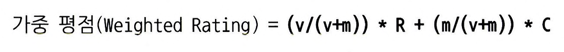

각 변수의 의미는 다음과 같습니다.

* v: 개별 영화에 평점을 투표한 횟수
* m: 평점을 부여하기 위한 최소 투표 횟수
* R: 개별 영화에 대한 평균 평점
* C: 전체 영화에 대한 평균 평점

V는 movies_df의 'vate_count' 값이며, R 값은 'vate_average'값에 해당합니다. C의 경우 전체 영화의 평균 평점이므로 moves_df['vote_average'].mean()으로 구할 수 있습니다. m의 경우는 투표 횟수에 따른 가중치를 직접 조절하는 역할을 하는데, m 값을 높이면 평점 투표 횟수가 많은 영화에 더 많은 가중 평점을 부여합니다. m 값은 전체 투표 횟수에서 상위 60%에 해당하는 횟수를 기준으로 정하겠습니다. 상위 60% 값은 Series 객체의 quantile()을 이용해 추출합니다.

In [19]:
C = movies_df['vote_average'].mean()
m = movies_df['vote_count'].quantile(0.6)
print('C:', round(C, 3), 'm:', round(m, 3))

C: 6.092 m: 370.2


기존 평점을 새로운 가중 평점으로 변경하는 함수를 생성하고 이를 이용해 새로운 평점 정보인 'vote_weighted' 값을 만들겠습니다. 함수명은 weighted_vote_average( )입니다. 이 함수는 DataFrame의 레코드를 인자로 받아 이 레코드의 vote_count와 vote_averate 칼럼, 그리고 미리 추출된 m과 C 값을 적용해 레코드별 가중 평점을 반환합니다. 해당 함수를 movies_df의 apply() 함수의 인자로 입력해 가중 평점을 계산하겠습니다.

In [20]:
percentile = 0.6
m = movies_df['vote_count'].quantile(percentile)
C = movies_df['vote_average'].mean()

def weighted_vote_average(record):
  v = record['vote_count']
  R = record['vote_average']

  return ( (v/(v+m)) * R ) + ( (m/(m+v)) * C)

movies_df['weighted_vote'] = movies.apply(weighted_vote_average, axis=1)

새롭게 부여된 weighted_vate 평점이 높은 순으로 상위 10개의 영화를 추출해 보겠습니다.

In [21]:
movies_df[['title', 'vote_average', 'weighted_vote', 'vote_count']].sort_values('weighted_vote', ascending=False)[:10]

,title,vote_average,weighted_vote,vote_count
1881,The Shawshank Redemption,8.5,8.396052,8205
3337,The Godfather,8.4,8.263591,5893
662,Fight Club,8.3,8.216455,9413
3232,Pulp Fiction,8.3,8.207102,8428
65,The Dark Knight,8.2,8.136930,12002
1818,Schindler's List,8.3,8.126069,4329
3865,Whiplash,8.3,8.123248,4254
809,Forrest Gump,8.2,8.105954,7927
2294,Spirited Away,8.3,8.105867,3840
2731,The Godfather: Part II,8.3,8.079586,3338


TOP 10에 대한 개인별 성향이 조금씩 달라서 위 결과에 이의가 있을지는 몰라도 위 영화 모두 매우 뛰어난 영화라는 점에는 이견이 없을 것입니다.

이제 새롭게 정의된 평점 기준에 따라서 영화를 추천해 보겠습니다. 장르 유사성이 높은 영화를 top_n의 2배수만큼 후보군으로 선정한 뒤에 weighted_vote 칼럼 값이 높은 순으로 top_n만큼 추출하는 방식으로 find_sim_movie () 함수를 변경합니다. 변경된 find_sim_movie()를 이용해 다시 한번 '대부'와 유사한 영화를 콘텐츠 기반 필터링 방식으로 추천해 보겠습니다.

In [22]:
def find_sim_movies(df, sorted_ind, title_name, top_n=10):
  title_movie = df[df['title'] == title_name]
  title_index = title_movie.index.values

  # top_n의 2배에 해당하는 장르 유사성이 높은 인덱스 추출
  similar_indexes = sorted_ind[title_index, :(top_n*2)]
  similar_indexes = similar_indexes.reshape(-1)
  # 기준 영화 인덱스는 제외
  similar_indexes = similar_indexes[similar_indexes != title_index]

  # top_n의 2배에 해당하는 후보군에서 weighted_vate가 높은 순으로 top_n만큼 추출
  return df.iloc[similar_indexes].sort_values('weighted_vote', ascending=False)[:top_n]

similar_movies = find_sim_movies(movies_df, genre_sim_sorted_ind, 'The Godfather', 10)
similar_movies[['title', 'vote_average', 'weighted_vote']]

,title,vote_average,weighted_vote
1881,The Shawshank Redemption,8.5,8.396052
2731,The Godfather: Part II,8.3,8.079586
1847,GoodFellas,8.2,7.976937
3866,City of God,8.1,7.759693
1663,Once Upon a Time in America,8.2,7.657811
3887,Trainspotting,7.8,7.591009
883,Catch Me If You Can,7.7,7.557097
892,Casino,7.8,7.423040
4041,This Is England,7.4,6.739664
1149,American Hustle,6.8,6.717525


이전에 추천된 영화보다 훨씬 나은 영화가 추천됐습니다. 특히 '원스 어폰 어 타임 인 아메리카(Once Upon a Time in America)'가 추천됐는데, 대부를 좋아하는 사람이라면 공감할 만한 추천 영화입니다. 하지만 장르만으로 영화가 전달하는 많은 요소와 분위기, 그리고 개인이 좋아하는 성향을 반영하기에는 부족할 수 있습니다. 아마 좋아하는 영화배우나 감독을 보고 영화를 선택하는 경우가 더 많을 것입니다. 앞의 장르를 기반으로 한 콘텐츠 필터링 예제를 좀 더 다양한 콘텐츠 기반으로 확장될 수 있습니다. 아쉽지만 다른 콘텐츠 기반으로 확장해 추천 시스템을 고도화하는 부분은 숙제로 남겨두고, 이어서 아이템 기반 최근접 이웃 협업 필터링을 구현해 보겠습니다.

## 06. 아이템 기반 최근접 이웃 협업 필터링 실습
최근접 이웃 협업 필터링은 사용자 기반과 아이템 기반으로 분류합니다. 이 중 일반적으로 추천 정확도가 더 뛰어난 아이템 기반의 협업 필터링을 구현해 보겠습니다. 협업 필터링 기반의 영화추천을 위해서는 사용자가 영화의 평점을 매긴 사용자-영화 평점 행렬 데이터 세트가 필요합니다.

## 데이터 가공 및 변환

In [25]:
import pandas as pd
import numpy as np

movies = pd.read_csv('/content/movies.csv')
ratings = pd.read_csv('/content/ratings.csv')
print(movies.shape)
print(ratings.shape)

(9742, 3)
(100836, 4)


movies.csv 파일을 영화에 대한 메타 정보인 title과 genres를 가지고 있는 영화 정보입니다.

ratings.csv 파일은 사용자별로 영화에 대한 평점을 매긴 데이터 세트입니다. 100,836개의 레코드 세트로서 사용자 아이디를 의미하는 userid, 영화(아이템) 아이디를 의미하는 movield, 그리고 평점인 rating 칼럼으로 구성됩니다. timestamp는 현재로서는 큰 의미가 없는 칼럼입니다. 평점은 최소 0.5에서 최대 5점 사이이며, 0.5 단위로 평점이 부여됩니다.

협업 필터링은 이 ratings.csv 데이터 세트와 같이 사용자와 아이템 간의 평점(또는 다른 유형의 액션)에 기반해 추천하는 시스템입니다. ratings.csv의 DataFrame인 ratings를 이용해 아이템 기반의 최근접 이웃 협업 필터링을 구현해 보겠습니다. 먼저 로우(행) 레벨 형태의 원본 데이터 세트를 모든 사용자를 로우로, 모든 영화를 칼럼으로 구성한 데이터 세트로 변경해야 합니다.

이 같은 변환은 DataFrame의 pivot_table() 함수를 이용하면 쉽게 할 수 있습니다. pivot_table() 함수를 로우 레벨의 값을 칼럼으로 변경하는 데 효과적입니다. pivot_table()에 인자로 columns='movieId'와 같이 부여하면 movieId 칼럼의 모든 값이 새로운 칼럼 이름으로 변환됩니다. ratings.pivot_table('ratind', index='userId', columns='moviesId')와 같이 호출하면 로우(행) 레벨은 userId, 칼럼은 모두 moviesId 칼럼에 있는 값으로 칼럼 이름이 바뀌고, 데이터는 rating 칼럼에 있는 값이 할당됩니다.

In [26]:
ratings = ratings[['userId', 'movieId', 'rating']]
ratings_matrix = ratings.pivot_table('rating', index='userId', columns='movieId')
ratings_matrix.head(3)

movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,4.0,NaN,4.0,NaN,NaN,4.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


pivot_table( )을 적용한 후에 movield 값이 모두 칼럼명(1, 2, 3 ... 193609)으로 변환됐습니다. NaN 값이 많이 눈에 띕니다. NaN 값이 많은 이유는 사용자가 평점을 매기지 않은 영화가 칼럼으로 변환되면서 NaN으로 값이 할당됐기 때문입니다. 최소 평점이 0.5이므로 NaN은 모두 0으로 변환하겠습니다. 그전에 먼저, 칼럼명이 현재 movield 숫자 값 (1, 2, 3… )과 같이 할당돼 있어 사용자가 평점을 준 영화가 어떤 영화인지 알기 어렵습니다. 가독성을 높이기 위해 칼럼명을 movield가 아닌 영화명 title로 변경하겠습니다. 영화명은 ratings에 존재하지 않고 movies 데이터 세트에 존재합니다. ratings와 movies를 조인해 title 칼럼을 가져온 뒤에 pivot_table()의 인자로 columns에 'movield'가 아닌 'title'을 입력해 title로 피벗(pivot)하겠습니다. 이후에 NaN은 0으로 변환합니다.

In [27]:
# title 칼럼을 얻기 위해 movies와 조인
rating_movies = pd.merge(ratings, movies, on='movieId')

# columns='title'로 title 칼럼으로 피벗 수행.
ratings_matrix = rating_movies.pivot_table('rating', index='userId', columns='title')

# NaN 값을 모두 0으로 변환
ratings_matrix = ratings_matrix.fillna(0)
ratings_matrix.head(3)

title,'71 (2014),'Hellboy': The Seeds of Creation (2004),'Round Midnight (1986),'Salem's Lot (2004),'Til There Was You (1997),'Tis the Season for Love (2015),"'burbs, The (1989)",'night Mother (1986),(500) Days of Summer (2009),*batteries not included (1987),...,Zulu (2013),[REC] (2007),[REC]² (2009),[REC]³ 3 Génesis (2012),anohana: The Flower We Saw That Day - The Movie (2013),eXistenZ (1999),xXx (2002),xXx: State of the Union (2005),¡Three Amigos! (1986),À nous la liberté (Freedom for Us) (1931)
userId,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 영화 간 유사도 산출
이제 변환된 사용자-영화 평점 행렬 데이터 세트를 이용해 영화 간의 유사도를 측정하겠습니다. 영화 간의 유사도는 코사인 유사도를 기반으로 하고 사이킷런의 cosine_similarity()를 이용해 측정합니다. 지금 만든 ratings_matrix 데이터 세트에 cosine_similarity()를 적용하면 영화간 유사도를 측정할 수 없습니다. 다음 그림에서도 볼 수 있듯이 cosine_similaritiy() 함수는 행을 기준으로 서로 다른 행을 비교해 유사도를 산출합니다. 그런데 ratings_matrix는 userid가 기준인 행 레벨 데이터이므로 여기에 cosine_similarity()를 적용하면 영화 간의 유사도가 아닌 사용자 간의 유사도가 만들어집니다.

영화를 기준으로 cosine_similarity()를 적용하려면 현재의 ratings_matrix가 행 기준이 영화가 되고 열 기준이 사용자가 돼야 합니다. 그렇게 하려면 ratings_matrix 데이터의 행과 열의 위치를 변경하면 되는데, 판다스는 이 같은 전치 행렬 변경을 위해 transpose() 함수를 제공합니다. ratings_matrix에 transpose()를 적용해 행과 열을 서로 바꾼 새로운 행렬을 만들어 보겠습니다.

In [28]:
ratings_matrix_T = ratings_matrix.transpose()
ratings_matrix_T.head(3)

userId,1,2,3,4,5,6,7,8,9,10,...,601,602,603,604,605,606,607,608,609,610
title,,,,,,,,,,,,,,,,,,,,,
'71 (2014),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0
'Hellboy': The Seeds of Creation (2004),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
'Round Midnight (1986),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


ratings_matrix를 전치 행렬 형식으로 변경한 데이터 세트를 기반으로 영화의 코사인 유사도를 구해 보겠습니다. 그리고 좀 더 직관적인 영화의 유사도 값을 표현하기 위해 cosine_similarity()로 반환된 넘파이 행렬에 영화명을 매핑해 DataFrame으로 변환하겠습니다.

In [29]:
from sklearn.metrics.pairwise import cosine_similarity

item_sim = cosine_similarity(ratings_matrix_T, ratings_matrix_T)

# cosine_similarity()로 반환된 넘파이 행렬을 영화명을 매핑해 DataFrame으로 변환
item_sim_df = pd.DataFrame(data=item_sim, index=ratings_matrix.columns, columns=ratings_matrix.columns)
print(item_sim_df.shape)
item_sim_df.head(3)

(9719, 9719)


title,'71 (2014),'Hellboy': The Seeds of Creation (2004),'Round Midnight (1986),'Salem's Lot (2004),'Til There Was You (1997),'Tis the Season for Love (2015),"'burbs, The (1989)",'night Mother (1986),(500) Days of Summer (2009),*batteries not included (1987),...,Zulu (2013),[REC] (2007),[REC]² (2009),[REC]³ 3 Génesis (2012),anohana: The Flower We Saw That Day - The Movie (2013),eXistenZ (1999),xXx (2002),xXx: State of the Union (2005),¡Three Amigos! (1986),À nous la liberté (Freedom for Us) (1931)
title,,,,,,,,,,,,,,,,,,,,,
'71 (2014),1.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.141653,0.0,...,0.0,0.342055,0.543305,0.707107,0.0,0.0,0.139431,0.327327,0.0,0.0
'Hellboy': The Seeds of Creation (2004),0.0,1.000000,0.707107,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,...,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0
'Round Midnight (1986),0.0,0.707107,1.000000,0.0,0.0,0.0,0.176777,0.0,0.000000,0.0,...,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0


9719 로우인 ratings_matrix.transpose() 데이터 세트에 대해 cosine_simailarity()를 적용한 결과 9719 x 9719 Shape으로 영화의 유사도 행렬인 item_sim이 생성됐습니다. item_sim을 DataFrame으로 변환한 item_sim_df를 이용해 영화 '대부(Godfather, The (1972))'와 유사도가 높은 상위 6개 영화를 추출해 보겠습니다.

In [30]:
item_sim_df["Godfather, The (1972)"].sort_values(ascending=False)[:6]

,"Godfather, The (1972)"
title,
"Godfather, The (1972)",1.000000
"Godfather: Part II, The (1974)",0.821773
Goodfellas (1990),0.664841
One Flew Over the Cuckoo's Nest (1975),0.620536
Star Wars: Episode IV - A New Hope (1977),0.595317
Fargo (1996),0.588614


기준 영화인 '대부'를 제외하면 '대부-2편'이 가장 유사도가 높습니다. 그 뒤를 마틴 스콜세지 감독의 '좋은 친구들(Goodfellas)'이 잇고 있습니다. 앞의 콘텐츠 기반 필터링과 다른 점은 '뻐꾸기 둥지 위로 날아간 새(One Flew Over the Cuckoo’s Nest (1975))', '스타워즈 1 편(Star Mrs: Episode IV - A New Hope (1977))'과 같이 장르가 완전히 다른 영화도 유사도가 매우 높게 나타났다는 것입니다. 이번에는 다른 훌륭한 영화인 '인셉션'과 유사도가 높은 영화를 찾아보겠습니다. '인셉션' 자신은 유사도에서 제외합니다.

In [31]:
item_sim_df["Inception (2010)"].sort_values(ascending=False)[1:6]

,Inception (2010)
title,
"Dark Knight, The (2008)",0.727263
Inglourious Basterds (2009),0.646103
Shutter Island (2010),0.617736
"Dark Knight Rises, The (2012)",0.617504
Fight Club (1999),0.615417


'다크나이트'가 가장 유사도가 높습니다. 그 뒤를 이어서 주로 스릴러와 액션이 가미된 좋은 영화가 높은 유사도를 나타내고 있습니다. 만들어진 아이템 기반 유사도 데이터는 사용자의 평점 정보를 모두 취합해 영화에 따라 유사한 다른 영화를 추천할 수 있게 해줍니다. 이번에는 이 아이템 기반 유사도 데이터를 이용해 개인에게 특화된(Personalized) 영화추천 알고리즘을 만들어 보겠습니다.

## 아이템 기반 최근접 이웃 협업 필터링으로 개인화된 영화 추천

앞 예제에서 만든 아이템 기반의 영화 유사도 데이터는 모든 사용자의 평점을 기준으로 영화의 유사도를 생성했고, 이를 이용해 훌륭한 영화를 추천할 수 있었습니다. 하지만 이는 개인적인 취향을 반영하지 않고 영화 간의 유사도만을 가지고 추천한 것입니다. 이번 절에서는 영화 유사도 데이터를 이용해 최근접 이웃 협업 필터링으로 개인에게 최적화된 영화추천을 구현해 보겠습니다. 개인화된 영화추천의 가장 큰 특징은 개인이 아직 관람하지 않은 영화를 추천한다는 것입니다. 아직 관람하지 않은 영화에 대해서 아이템 유사도와 기존에 관람한 영화의 평점 데이터를 기반으로 해 새롭게 모든 영화의 예측 평점을 계산한 후 높은 예측 평점을 가진 영화를 추천하는 방식입니다.

이러한 아이템 기반의 협업 필터링에서 개인화된 예측 평점은 다음 식으로 구할 수 있습니다.

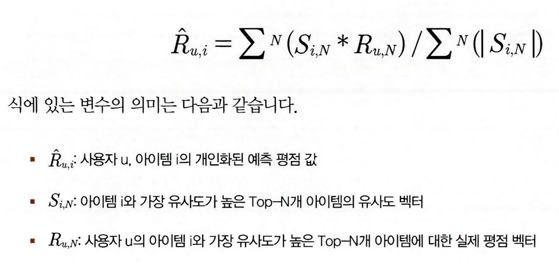

여기에서 Si,N와 Ru,N에 나오는 N 값은 아이템의 최근접 이웃 범위 계수(item neighbor)를 의미합니다. 이는 특정 아이템과 유사도가 가장 높은 Top-N개의 다른 아이템을 추출하는 데 사용됩니다. 먼저 N의 범위에 제약을 두지 않고 모든 아이템으로 가정하고 예측 평점을 구하는 로직을 작성한 뒤에 Top-N 아이템을 기반으로 협업 필터링을 수행하는 로직으로 변경하겠습니다.

앞 예제에서 생성된 영화 간의 유사도를 가지는 DataFrame인 item_sim_df와 사용자-영화 평점 DataFrame인 ratings_matrix 변수를 계속 활용해 사용자별로 최적화된 평점 스코어를 예측하는 함수를 만들겠습니다. 함수명은 predict_rating( )이며, 인자로 사용자-영화 평점 넘파이 행렬(rating_matrix를 넘파이 행렬로 변환)과 영화 간의 유사도를 가지는 넘파이 행렬(item_sim_df를 넘파이 행렬로 변환)을 입력받고 이를 이용해 개인화된 예측 평점을 계산합니다.

N의 범위에 제약을 두지 않는다면 사용자별 영화 예측 평점 Ru,i는 사용자 u의 모든 영화에 대한 실제 평점과 영화 i의 다른 모든 영화와의 코사인 유사도를 벡터 내적 곱(dot)한 값을 정규화를 위해 sigma N (|Si,N|)로 나눈 것을 의미합니다. 다음 코드는 이를 구현한 것입니다.

In [32]:
def predict_rating(ratings_arr, item_sim_arr):
  ratings_pred = ratings_arr.dot(item_sim_arr)/np.array([np.abs(item_sim_arr).sum(axis=1)])
  return ratings_pred

앞의 예제에서 ratings_arr.dot(item_sim_arr)은 sigma N (Si,N * R u,N)를 계산한 값입니다. np.array([np.abs(item_sim_arr).sum(axis=l)]은 sigmaN(|Si,N|)를 계산한 값입니다.

predict_rating( ) 함수를 이용해 개인화된 예측 평점을 구해 보겠습니다. ratings_matrix와 item_sim_df를 넘파이 행렬로 변환해 인자로 입력합니다.

In [33]:
ratings_pred = predict_rating(ratings_matrix.values, item_sim_df.values)
ratings_pred_matrix = pd.DataFrame(data=ratings_pred, index=ratings_matrix.index, \
                                   columns=ratings_matrix.columns)
ratings_pred_matrix.head(3)

title,'71 (2014),'Hellboy': The Seeds of Creation (2004),'Round Midnight (1986),'Salem's Lot (2004),'Til There Was You (1997),'Tis the Season for Love (2015),"'burbs, The (1989)",'night Mother (1986),(500) Days of Summer (2009),*batteries not included (1987),...,Zulu (2013),[REC] (2007),[REC]² (2009),[REC]³ 3 Génesis (2012),anohana: The Flower We Saw That Day - The Movie (2013),eXistenZ (1999),xXx (2002),xXx: State of the Union (2005),¡Three Amigos! (1986),À nous la liberté (Freedom for Us) (1931)
userId,,,,,,,,,,,,,,,,,,,,,
1,0.070345,0.577855,0.321696,0.227055,0.206958,0.194615,0.249883,0.102542,0.157084,0.178197,...,0.113608,0.181738,0.133962,0.128574,0.006179,0.212070,0.192921,0.136024,0.292955,0.720347
2,0.018260,0.042744,0.018861,0.000000,0.000000,0.035995,0.013413,0.002314,0.032213,0.014863,...,0.015640,0.020855,0.020119,0.015745,0.049983,0.014876,0.021616,0.024528,0.017563,0.000000
3,0.011884,0.030279,0.064437,0.003762,0.003749,0.002722,0.014625,0.002085,0.005666,0.006272,...,0.006923,0.011665,0.011800,0.012225,0.000000,0.008194,0.007017,0.009229,0.010420,0.084501


예측 평점이 사용자별 영화의 실제 평점과 영화의 코사인 유사도를 내적(dot)한 값이기 때문에 기존에 영화를 관람하지 않아 0에 해당했던 실제 영화 평점이 예측에서는 값이 부여되는 경우가 많이 발생합니다. 예측 평점이 실제 평점에 비해 작을 수 있습니다. 이는 내적 결과를 코사인 유사도 벡터 합으로 나누었기 때문에 생기는 현상입니다.

이 예측 결과가 원래의 실제 평점과 얼마나 차이가 있는지 확인해 보겠습니다. 예측 평가 지표는 MSE를 적용하겠습니다. MSE를 측정할 때 유의할 점이 있습니다. 사용자가 영화의 평점을 주지 않은 경우 앞에서는 평점을 0으로 부과했습니다. 하지만 앞에서 개인화된 예측 점수는 평점을 주지 않은 영화에 대해서도 아이템 유사도에 기반해 평점을 예측했습니다. 따라서 실제와 예측 평점의 차이는 기존에 평점이 부여된 데이터에 대해서만 오차 정도를 측정하겠습니다. 예측 평가 지표인 MSE를 계산하는 get_mse() 함수를 만들고 결과를 확인합니다.

In [34]:
from sklearn.metrics import mean_squared_error

# 사용자가 평점을 부여한 영화에 대해서만 예측 성능 평가 MSE를 구함.
def get_mse(pred, actual):
  # 평점이 있는 실제 영화만 추출
  pred = pred[actual.nonzero()].flatten()
  actual = actual[actual.nonzero()].flatten()
  return mean_squared_error(pred, actual)

print('아이템 기반 모든 최근접 이웃 MSE: ', get_mse(ratings_pred, ratings_matrix.values))

아이템 기반 모든 최근접 이웃 MSE:  9.895354759094706


MSE가 약 9.89입니다. 실제 값과 예측값은 서로 스케일이 다르기 때문에 MSE가 클 수도 있습니다. 중요한 것은 MSE를 감소시키는 방향으로 개선하는 것입니다.

앞의 predict_rating() 함수는 사용자별 영화의 예측 평점을 계산하기 위해 해당 영화와 다른 모든 영화 간의 유사도 벡터를 적용한 것입니다. 많은 영화의 유사도 벡터를 이용하다 보니 상대적으로 평점 예측이 떨어졌습니다. 특정 영화와 가장 비슷한 유사도를 가지는 영화에 대해서만 유사도 벡터를 적용하는 함수로 변경하겠습니다. predict_rating_topsim(ratings_arr, item_sim_arr, n=20)함수는 predict_rating() 함수와 유사하지만 n 인자를 가지고 있어서 Top-N 유사도를 가지는 영화 유사도 벡터만 예측값을 계산하는 데 적용합니다. 아쉬운 점은 이러한 계산을 위해서는 개별 예측값을 구하기 위해서 행, 열 별로 for 루프를 반복 수행하면서 Top-N 유사도 벡터를 계산해야 하기 때문에 수행시간이 오래 걸린다는 점입니다.

In [35]:
def predict_rating_topsim(ratings_arr, item_sim_arr, n=20):
  # 사용자-아이템 평점 행렬 크기만큼 0으로 채운 예측 행렬 초기화
  pred = np.zeros(ratings_arr.shape)

  # 사용자-아이템 평점 행렬의 열 크기만큼 루프 수행.
  for col in range(ratings_arr.shape[1]):
    # 유사도 행렬에서 유사도가 큰 순으로 n개 데이터 행렬의 인덱스 반환
    top_n_items = [np.argsort(item_sim_arr[:, col])[:-n-1:-1]]
    # 개인화된 예측 평점을 계산
    for row in range(ratings_arr.shape[0]):
      pred[row, col] = item_sim_arr[col,:][top_n_items].dot(ratings_arr[row,:][top_n_items].T)
      pred[row, col] /= np.sum(np.abs(item_sim_arr[col,:][top_n_items]))

  return pred

predict_rating_topsim() 함수를 이용해 예측 평점을 계산하고, 실제 평점과의 MSE를 구해 보겠습니다. 계산된 예측 평점 넘파이 행렬은 판다스 DataFrame으로 재생성하겠습니다.

In [36]:
ratings_pred = predict_rating_topsim(ratings_matrix.values, item_sim_df.values, n=20)
print('아이템 기반 최근접 Top-20 이웃 MSE：', get_mse(ratings_pred, ratings_matrix.values))

# 계산된 예측 평점 데이터는 DataFrame으로 재생성
ratings_pred_matrix = pd.DataFrame(data=ratings_pred, index= ratings_matrix.index, columns = ratings_matrix.columns)

아이템 기반 최근접 Top-20 이웃 MSE： 3.694409449382562


MSE가 약 3.69로 기존의 9.89보다 많이 향상됐습니다. 이제 특정 사용자에 대해 영화를 추천해 보겠습니다. userid = 9인 사용자에 대해 영화를 추천해 보겠습니다. 먼저 9번 userid 사용자가 어떤 영화를 좋아하는지 확인해 보겠습니다. 사용자가 평점을 준 영화를 평점이 높은 순으로 나열해 보겠습니다.

In [37]:
user_rating_id = ratings_matrix.loc[9, :]
user_rating_id[ user_rating_id > 0].sort_values(ascending=False)[:10]

,9
title,
Adaptation (2002),5.0
Austin Powers in Goldmember (2002),5.0
Back to the Future (1985),5.0
Citizen Kane (1941),5.0
"Lord of the Rings: The Fellowship of the Ring, The (2001)",5.0
"Lord of the Rings: The Two Towers, The (2002)",5.0
"Producers, The (1968)",5.0
Raiders of the Lost Ark (Indiana Jones and the Raiders of the Lost Ark) (1981),5.0
Elling (2001),4.0


'반지의 제왕', '오스틴 파워' 등 대작 영화나 어드벤처 영화, 코미디 영화 등 전반적으로 흥행성이 좋은 영화에 높은 평점을 주고 있습니다. 이 사용자에게 아이템 기반 협업 필터링을 통해 영화를 추천하겠습니다. 먼저 사용자가 이미 평점을 준 영화를 제외하고 추천할 수 있도록 평점을 주지 않은 영화를 리스트 객체로 반환하는 함수인 get_unseen_movies()를 생성합니다.

In [38]:
def get_unseen_movies(ratings_matrix, userId):
  # userId로 입력받은 사용자의 모든 영화 정보를 추출해 Series로 반환함.
  # 반환된 user_rating은 영화명(title)을 인덱스로 가지는 Series 객체임.
  user_rating = ratings_matrix.loc[userId, :]

  # user_rating이 0보다 크면 기존에 관람한 영화임. 대상 인덱스를 추출해 list 객체로 만듦.
  already_seen = user_rating[user_rating > 0].index.tolist()

  # 모든 영화명을 list 객체로 만듦.
  movies_list = ratings_matrix.columns.tolist()

  # list comprehension으로 already_seem에 해당하는 영화는 movies_list에서 제외함.
  unseen_list = [movie for movie in movies_list if movie not in already_seen]

  return unseen_list

사용자가 영화의 평점을 주지 않은 추천 대상 영화 정보와 predict_rating_topsim( )에서 추출한 사용자별 아이템 유사도에 기반한 예측 평점 데이터 세트를 이용해 최종적으로 사용자에게 영화를 추천하는 함수인 recomm_movie_by_userid()를 만들어 보겠습니다. 해당 함수는 예측 평점 DataFrame과 추천하려는 사용자id, 추천 후보 영화 리스트, 추천 상위 영화 개수를 인자로 받아서 사용자가 좋아할 만한 가장 높은 예측 평점을 가진 영화를 추천해 줍니다.

In [39]:
def recomm_movie_by_userid(pred_df, userId, unseen_list, top_n=10):
  #  예측 평점 DataFrame에서 사용자id 인덱스와 unseen_list로 들어온 영화명 칼럼을 추출해
  # 가장 예측 평점이 높은 순으로 정렬함.
  recomm_movies = pred_df.loc[userId, unseen_list].sort_values(ascending=False)[:top_n]
  return recomm_movies

# 사용자가 관람하지 않은 영화명 추출
unseen_list = get_unseen_movies(ratings_matrix, 9)

# 아이템 기반의 최근접 이웃 협업 필터링으로 영화 추천
recomm_movies = recomm_movie_by_userid(ratings_pred_matrix, 9, unseen_list, top_n=10)

# 평점 데이터를 DataFrame으로 생성
recomm_movies = pd.DataFrame(data=recomm_movies.values, index=recomm_movies.index, columns=['pred_score'])
recomm_movies

,pred_score
title,
Shrek (2001),0.866202
Spider-Man (2002),0.857854
"Last Samurai, The (2003)",0.817473
Indiana Jones and the Temple of Doom (1984),0.816626
"Matrix Reloaded, The (2003)",0.800990
Harry Potter and the Sorcerer's Stone (a.k.a. Harry Potter and the Philosopher's Stone) (2001),0.765159
Gladiator (2000),0.740956
"Matrix, The (1999)",0.732693
Pirates of the Caribbean: The Curse of the Black Pearl (2003),0.689591


'슈렉', '스파이더 맨', '인디아나 존스-2편', '매트릭스' 등 다양하지만 높은 흥행성을 가진 작품이 추천 됐습니다.